In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("hf://datasets/AbdulHadi806/mail_spam_ham_dataset/mail_data.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print(df.shape)
print("-" * 50)
print(df.columns)
print("-" * 50)
print(df.info())

(5613, 2)
--------------------------------------------------
Index(['Category', 'Message'], dtype='object')
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5613 entries, 0 to 5612
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5613 non-null   object
 1   Message   5613 non-null   object
dtypes: object(2)
memory usage: 87.8+ KB
None


In [11]:
print(df.isna().sum())
print("-" * 50)
print(df.duplicated().sum())

Category    0
Message     0
dtype: int64
--------------------------------------------------
425


In [9]:
df["Category"].value_counts()

Category
ham     4845
spam     768
Name: count, dtype: int64

In [8]:
X = df["Message"]
y = df["Category"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1
)
X_train.head()

1235    Hello-/@drivby-:0quit edrunk sorry iff pthis m...
4234    My love ... I hope your not doing anything dra...
5129    Rose for red,red for blood,blood for heart,hea...
3073                               Ok lor... But buy wat?
2478    I'm done. I'm sorry. I hope your next space gi...
Name: Message, dtype: object

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [12]:
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

In [13]:
nb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [14]:
y_pred = nb_model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9590382902938558
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       969
        spam       1.00      0.70      0.82       154

    accuracy                           0.96      1123
   macro avg       0.98      0.85      0.90      1123
weighted avg       0.96      0.96      0.96      1123



In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9732858414959928
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       969
        spam       0.99      0.81      0.89       154

    accuracy                           0.97      1123
   macro avg       0.98      0.91      0.94      1123
weighted avg       0.97      0.97      0.97      1123



In [17]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9928762243989314
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       969
        spam       0.99      0.96      0.97       154

    accuracy                           0.99      1123
   macro avg       0.99      0.98      0.98      1123
weighted avg       0.99      0.99      0.99      1123



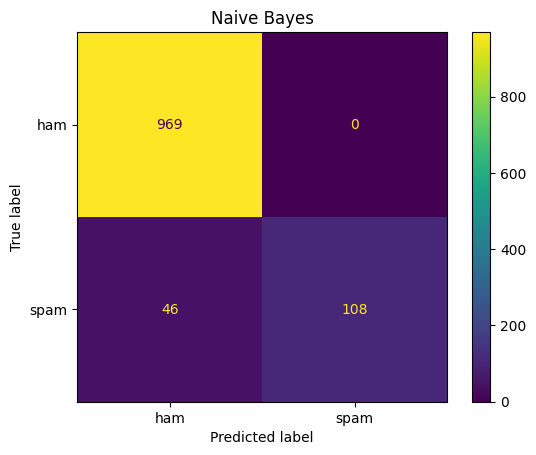

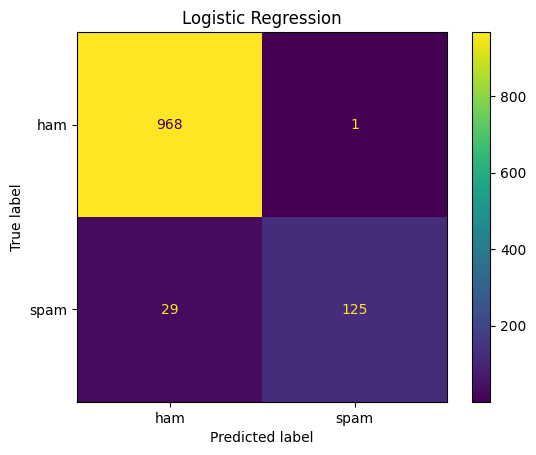

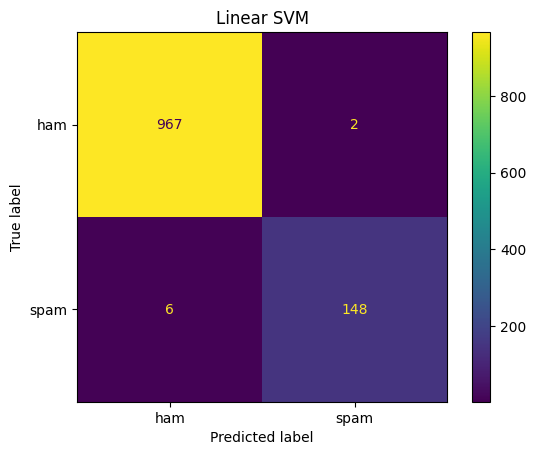

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_nb = confusion_matrix(y_test, y_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot()
plt.title("Naive Bayes")
plt.show()

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot()
plt.title("Logistic Regression")
plt.show()

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp_svm.plot()
plt.title("Linear SVM")
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models_preds = {
    "Naive Bayes": y_pred,
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm
}

for name, preds in models_preds.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (spam)": precision_score(y_test, preds, pos_label="spam"),
        "Recall (spam)": recall_score(y_test, preds, pos_label="spam"),
        "F1-score (spam)": f1_score(y_test, preds, pos_label="spam")
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="F1-score (spam)", ascending=False)

,Model,Accuracy,Precision (spam),Recall (spam),F1-score (spam)
2,Linear SVM,0.992876,0.986667,0.961039,0.973684
1,Logistic Regression,0.973286,0.992063,0.811688,0.892857
0,Naive Bayes,0.959038,1.000000,0.701299,0.824427


In [26]:
import joblib

best_model = svm_model
joblib.dump(best_model, "../models/spam_classifier_linear_svm.joblib")

['../models/spam_classifier_linear_svm.joblib']

In [28]:
from pathlib import Path

model_path = Path("../models/spam_classifier_linear_svm.joblib")
size_bytes = model_path.stat().st_size
size_mb = size_bytes / (1024 * 1024)

print(f"Size: {size_bytes} bytes")
print(f"Size: {size_mb:.2f} MB")

Size: 218560 bytes
Size: 0.21 MB
